In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import arviz as az
from cmdstanpy import CmdStanModel

np.random.seed(42)
az.style.use('arviz-darkgrid')

/usr/local/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
data = pd.read_csv('data/IMDbMovies-Clean.csv')
data.head()

,Title,Summary,Director,Writer,Main Genres,Motion Picture Rating,Release Year,Runtime (Minutes),Rating (Out of 10),Number of Ratings (in thousands),Budget (in millions),Gross in US & Canada (in millions),Gross worldwide (in millions),Opening Weekend in US & Canada,Gross Opening Weekend (in millions)
0,Napoleon,An epic that details the checkered rise and fa...,Ridley Scott,David Scarpa,"Action,Adventure,Biography",R,2023.0,158.0,6.7,38.0,NaN,37.514,84.968,11.26.2023,20.639
1,The Hunger Games: The Ballad of Songbirds & Sn...,Coriolanus Snow mentors and develops feelings ...,Francis Lawrence,"Michael Lesslie,Michael Arndt,Suzanne Collins","Action,Adventure,Drama",PG-13,2023.0,157.0,7.2,37.0,100.0,105.043,191.729,11.19.2023,44.607
2,The Killer,"After a fateful near-miss, an assassin battles...",David Fincher,"Andrew Kevin Walker,Luc Jacamon,Alexis Nolent","Action,Adventure,Crime",R,2023.0,118.0,6.8,117.0,NaN,NaN,0.421,NaN,NaN
3,Leo,A 74-year-old lizard named Leo and his turtle ...,"David Wachtenheim,Robert Smigel,Robert Marianetti","Paul Sado,Robert Smigel,Adam Sandler","Animation,Comedy,Family",PG,2023.0,102.0,7.0,10.0,NaN,NaN,NaN,NaN,NaN
4,Thanksgiving,"After a Black Friday riot ends in tragedy, a m...",Eli Roth,"Eli Roth,Jeff Rendell","Horror,Mystery,Thriller",R,2023.0,106.0,7.0,9.1,NaN,25.409,29.667,11.19.2023,10.306


In [4]:
df_clean = data[['Title', 'Main Genres', 'Motion Picture Rating', 'Rating (Out of 10)', 'Number of Ratings (in thousands)', 'Budget (in millions)', 'Gross worldwide (in millions)']].dropna()
df_clean = df_clean[df_clean['Motion Picture Rating'].isin(['R', 'PG-13'])].copy()
df_clean['is_pg13'] = (df_clean['Motion Picture Rating'] == 'PG-13').astype(int)

dark_genres = 'Action|Horror|Thriller'
df_clean['is_dark_genre'] = df_clean['Main Genres'].str.contains(dark_genres).astype(int)

df_clean = df_clean[(df_clean['Budget (in millions)'] > 0) & (df_clean['Gross worldwide (in millions)'] > 0)]

df_clean['log_budget'] = np.log(df_clean['Budget (in millions)'])
df_clean['std_budget'] = (df_clean['log_budget'] - df_clean['log_budget'].mean()) / df_clean['log_budget'].std()

df_clean['log_gross'] = np.log(df_clean['Gross worldwide (in millions)'])
df_clean['std_gross'] = (df_clean['log_gross'] - df_clean['log_gross'].mean()) / df_clean['log_gross'].std()

rating_data_baseline = {
    "N": len(df_clean),
    "y": df_clean["Rating (Out of 10)"].values,
    "is_dark_genre": df_clean["is_dark_genre"].values,
    "budget": df_clean["std_budget"].values
}
rating_data_extended = {
    "N": len(df_clean),
    "y": df_clean["Rating (Out of 10)"].values,
    "is_pg13": df_clean["is_pg13"].values,
    "is_dark_genre": df_clean["is_dark_genre"].values,
    "budget": df_clean["std_budget"].values
}
revenue_data_baseline = {
    "N": len(df_clean),
    "y": df_clean["std_gross"].values,
    "is_dark_genre": df_clean["is_dark_genre"].values,
    "budget": df_clean["std_budget"].values
}
revenue_data_extended = {
    "N": len(df_clean),
    "y": df_clean["std_gross"].values,
    "is_pg13": df_clean["is_pg13"].values,
    "is_dark_genre": df_clean["is_dark_genre"].values,
    "budget": df_clean["std_budget"].values
}

In [5]:
model1_baseline = CmdStanModel(stan_file='stan/model1_baseline.stan')
model1_extended = CmdStanModel(stan_file='stan/model1_extended.stan')


INFO:cmdstanpy:found newer exe file, not recompiling
INFO:cmdstanpy:found newer exe file, not recompiling


## Rating analysis

#### Fit models

In [6]:
fit_model1_baseline_rating = model1_baseline.sample(data=rating_data_baseline, chains=4, iter_sampling=1000, parallel_chains=4)
fit_model1_extended_rating = model1_extended.sample(data=rating_data_extended, chains=4, iter_sampling=1000, parallel_chains=4)

INFO:cmdstanpy:CmdStan start processing
chain 1 |          | 00:00 Status



chain 1 |▍         | 00:00 Status




chain 1 |▉         | 00:00 Iteration:    1 / 2000 [  0%]  (Warmup)


chain 1 |█▎        | 00:00 Iteration:  100 / 2000 [  5%]  (Warmup)


chain 1 |█▊        | 00:01 Iteration:  200 / 2000 [ 10%]  (Warmup)


chain 1 |██▎       | 00:01 Iteration:  300 / 2000 [ 15%]  (Warmup)


chain 1 |██▋       | 00:02 Iteration:  400 / 2000 [ 20%]  (Warmup)


chain 1 |███▏      | 00:02 Iteration:  500 / 2000 [ 25%]  (Warmup)


chain 1 |███▋      | 00:02 Iteration:  600 / 2000 [ 30%]  (Warmup)
chain 1 |████      | 00:02 Iteration:  700 / 2000 [ 35%]  (Warmup)

chain 1 |████▌     | 00:03 Iteration:  800 / 2000 [ 40%]  (Warmup)




chain 1 |█████     | 00:03 Iteration:  900 / 2000 [ 45%]  (Warmup)


chain 1 |█████▉    | 00:04 Iteration: 1001 / 2000 [ 50%]  (Sampling)


chain 1 |██████▎   | 00:05 Iteration: 1100 / 2000 [ 55%]  (Sampling)


chain 1 |██████▊   | 00:07 Iteration: 1200 / 2000 [ 60


INFO:cmdstanpy:CmdStan done processing.


INFO:cmdstanpy:CmdStan start processing
chain 1 |          | 00:00 Status


chain 1 |▍         | 00:00 Status


chain 1 |▉         | 00:01 Iteration:    1 / 2000 [  0%]  (Warmup)



chain 1 |█▎        | 00:04 Iteration:  100 / 2000 [  5%]  (Warmup)


chain 1 |█▊        | 00:06 Iteration:  200 / 2000 [ 10%]  (Warmup)


chain 1 |██▎       | 00:07 Iteration:  300 / 2000 [ 15%]  (Warmup)


chain 1 |██▋       | 00:10 Iteration:  400 / 2000 [ 20%]  (Warmup)


chain 1 |███▏      | 00:11 Iteration:  500 / 2000 [ 25%]  (Warmup)




chain 1 |███▋      | 00:14 Iteration:  600 / 2000 [ 30%]  (Warmup)
chain 1 |████      | 00:16 Iteration:  700 / 2000 [ 35%]  (Warmup)




chain 1 |████▌     | 00:17 Iteration:  800 / 2000 [ 40%]  (Warmup)
chain 1 |█████     | 00:19 Iteration:  900 / 2000 [ 45%]  (Warmup)


chain 1 |█████▉    | 00:22 Iteration: 1001 / 2000 [ 50%]  (Sampling)


chain 1 |██████▎   | 00:24 Iteration: 1100 / 2000 [ 55%]  (Sampling)


chain 1 |██████▊   | 00:27 Iteration: 1200 / 2000 [ 60%


INFO:cmdstanpy:CmdStan done processing.


#### Compare with `az`

In [7]:
idata_model1_baseline_rating = az.from_cmdstanpy(fit_model1_baseline_rating)
idata_model1_extended_rating = az.from_cmdstanpy(fit_model1_extended_rating)

                             rank          loo      p_loo      d_loo  \
Extended model (With PG-13)     0 -5071.573471  10.401476   0.000000   
Base Model (Without PG-13)      1 -5128.774944   5.522587  57.201473   

                               weight         se   dse  warning loo_scale  
Extended model (With PG-13)  0.901119  56.651951   0.0    False       log  
Base Model (Without PG-13)   0.098881  56.623145  12.3    False       log  


<AxesSubplot:xlabel='Log'>

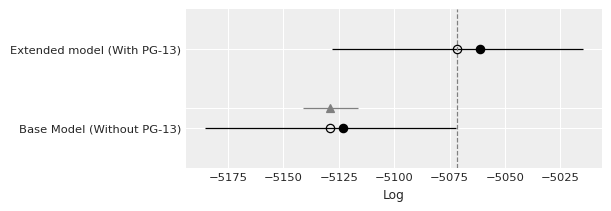

In [8]:
comp = az.compare({"Base Model (Without PG-13)": idata_model1_baseline_rating, "Extended model (With PG-13)": idata_model1_extended_rating}, ic="loo")
print(comp)

az.plot_compare(comp)

#### Analyze

array([<AxesSubplot:title={'center':'94.0% HDI'}>], dtype=object)

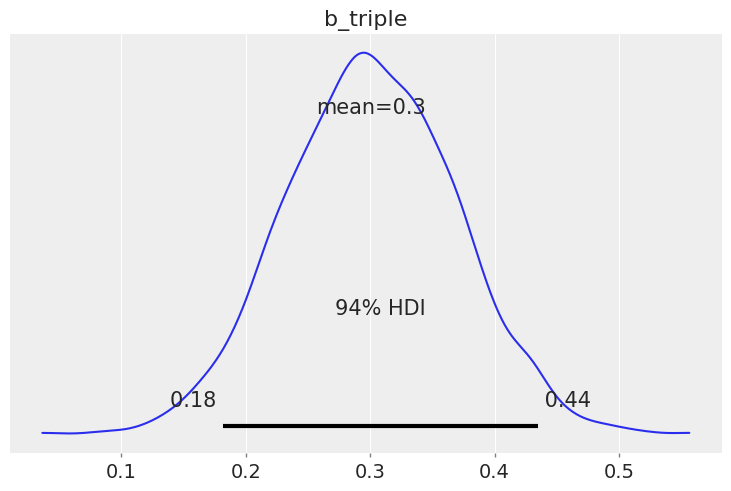

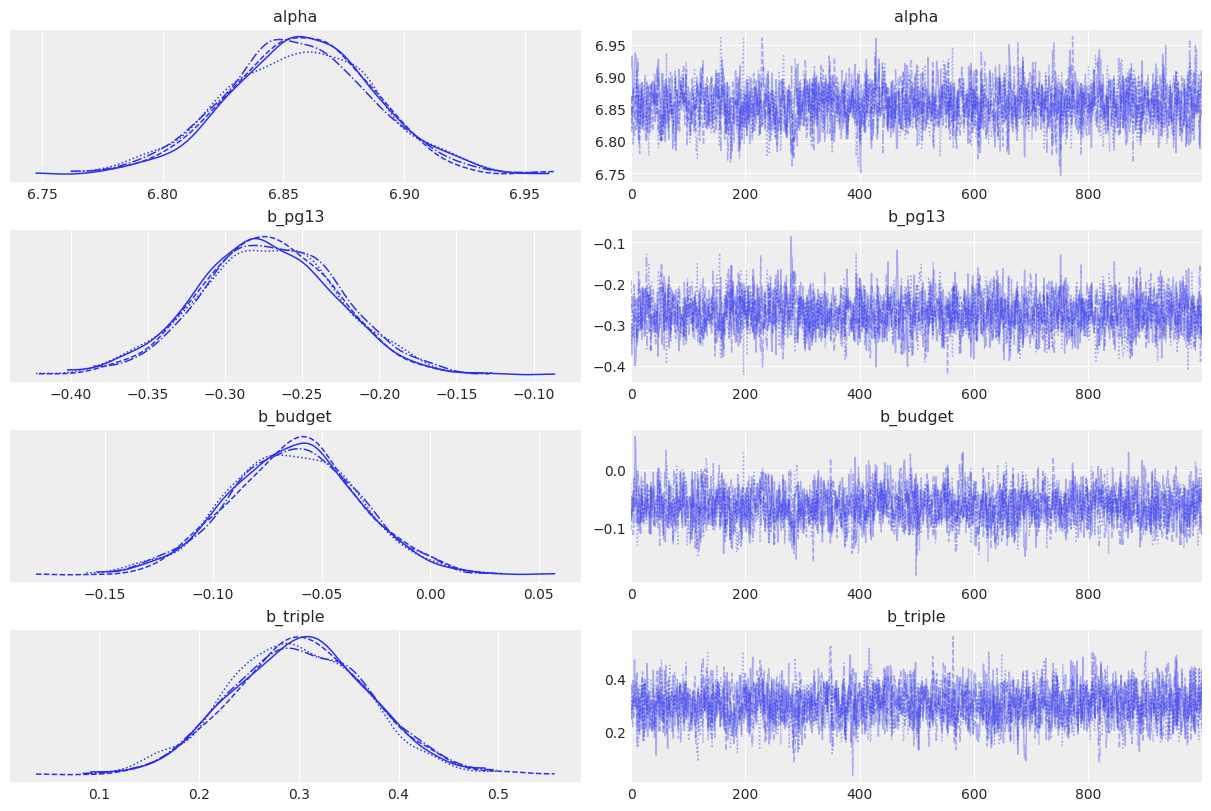

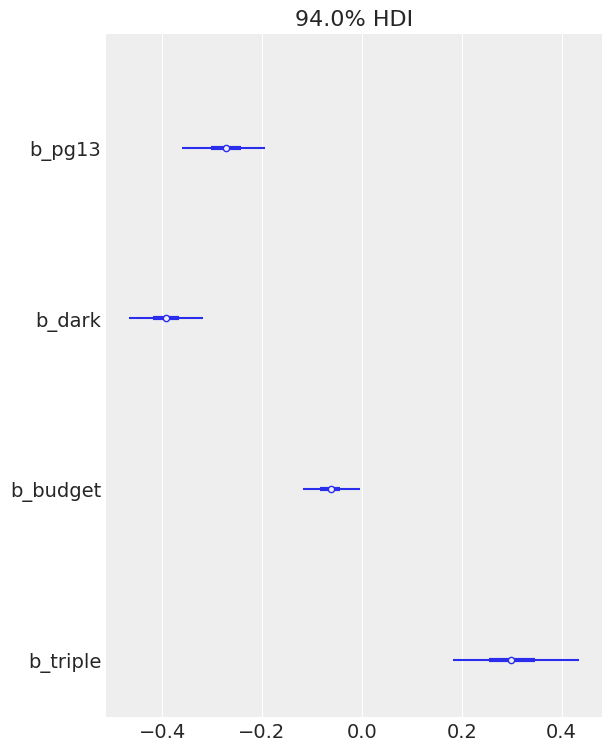

In [9]:
az.plot_posterior(idata_model1_extended_rating, var_names=['b_triple'])
az.plot_trace(idata_model1_extended_rating, var_names=['alpha', 'b_pg13', 'b_budget', 'b_triple'])
az.plot_forest(idata_model1_extended_rating, var_names=['b_pg13', 'b_dark', 'b_budget', 'b_triple'], combined=True, hdi_prob=0.94)

#### Posterior predictive distribution

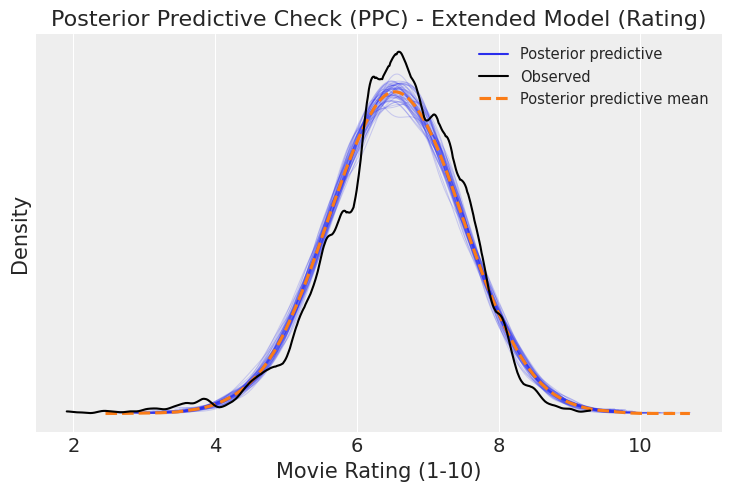

In [10]:
idata_extended_rating = az.from_cmdstanpy(
    posterior=fit_model1_extended_rating,
    posterior_predictive="y_rep",
    observed_data={"y": df_clean["Rating (Out of 10)"].values}
)

az.plot_ppc(idata_extended_rating, data_pairs={"y": "y_rep"}, num_pp_samples=50, kind="kde")

plt.title("Posterior Predictive Check (PPC) - Extended Model (Rating)")
plt.xlabel("Movie Rating (1-10)")
plt.ylabel("Density")
plt.show()

## Revenue analysis

#### Fit models

In [11]:
fit_model1_baseline_revenue = model1_baseline.sample(data=revenue_data_baseline, chains=4, iter_sampling=1000, parallel_chains=4)
fit_model1_extended_revenue = model1_extended.sample(data=revenue_data_extended, chains=4, iter_sampling=1000, parallel_chains=4)

INFO:cmdstanpy:CmdStan start processing
chain 1 |          | 00:00 Status


chain 1 |▍         | 00:00 Status




chain 1 |▉         | 00:00 Iteration:    1 / 2000 [  0%]  (Warmup)
chain 1 |█▎        | 00:00 Iteration:  100 / 2000 [  5%]  (Warmup)


chain 1 |█▊        | 00:00 Iteration:  200 / 2000 [ 10%]  (Warmup)


chain 1 |██▎       | 00:01 Iteration:  300 / 2000 [ 15%]  (Warmup)


chain 1 |██▋       | 00:01 Iteration:  400 / 2000 [ 20%]  (Warmup)


chain 1 |███▏      | 00:01 Iteration:  500 / 2000 [ 25%]  (Warmup)


chain 1 |███▋      | 00:01 Iteration:  600 / 2000 [ 30%]  (Warmup)


chain 1 |████      | 00:02 Iteration:  700 / 2000 [ 35%]  (Warmup)


chain 1 |████▌     | 00:02 Iteration:  800 / 2000 [ 40%]  (Warmup)


chain 1 |█████     | 00:02 Iteration:  900 / 2000 [ 45%]  (Warmup)


chain 1 |█████▉    | 00:03 Iteration: 1001 / 2000 [ 50%]  (Sampling)


chain 1 |██████▎   | 00:04 Iteration: 1100 / 2000 [ 55%]  (Sampling)


chain 1 |██████▊   | 00:05 Iteration: 1200 / 2000 [ 60%]


INFO:cmdstanpy:CmdStan done processing.


INFO:cmdstanpy:CmdStan start processing
chain 1 |          | 00:00 Status


chain 1 |▍         | 00:00 Status





chain 1 |▉         | 00:01 Iteration:    1 / 2000 [  0%]  (Warmup)


chain 1 |█▎        | 00:02 Iteration:  100 / 2000 [  5%]  (Warmup)


chain 1 |█▊        | 00:04 Iteration:  200 / 2000 [ 10%]  (Warmup)


chain 1 |██▎       | 00:06 Iteration:  300 / 2000 [ 15%]  (Warmup)


chain 1 |██▋       | 00:09 Iteration:  400 / 2000 [ 20%]  (Warmup)


chain 1 |███▏      | 00:10 Iteration:  500 / 2000 [ 25%]  (Warmup)


chain 1 |███▋      | 00:11 Iteration:  600 / 2000 [ 30%]  (Warmup)
chain 1 |████      | 00:12 Iteration:  700 / 2000 [ 35%]  (Warmup)


chain 1 |████▌     | 00:13 Iteration:  800 / 2000 [ 40%]  (Warmup)


chain 1 |█████     | 00:15 Iteration:  900 / 2000 [ 45%]  (Warmup)


chain 1 |█████▉    | 00:16 Iteration: 1001 / 2000 [ 50%]  (Sampling)


chain 1 |██████▎   | 00:18 Iteration: 1100 / 2000 [ 55%]  (Sampling)


chain 1 |██████▊   | 00:19 Iteration: 1200 / 2000 [ 60%


INFO:cmdstanpy:CmdStan done processing.


#### Compare with `az`

In [12]:
idata_model1_baseline_revenue = az.from_cmdstanpy(fit_model1_baseline_revenue)
idata_model1_extended_revenue = az.from_cmdstanpy(fit_model1_extended_revenue)

                             rank          loo      p_loo      d_loo  \
Extended model (With PG-13)     0 -4539.044923  15.923790   0.000000   
Base Model (Without PG-13)      1 -4577.112889  10.261131  38.067966   

                               weight         se       dse  warning loo_scale  
Extended model (With PG-13)  0.970636  81.861444  0.000000    False       log  
Base Model (Without PG-13)   0.029364  82.442985  9.429103    False       log  


<AxesSubplot:xlabel='Log'>

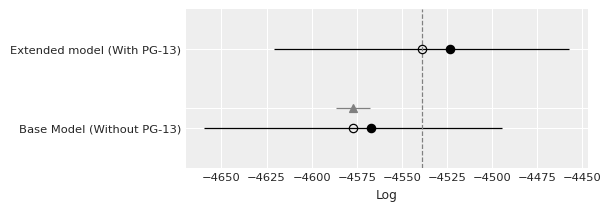

In [13]:
comp = az.compare({"Base Model (Without PG-13)": idata_model1_baseline_revenue, "Extended model (With PG-13)": idata_model1_extended_revenue}, ic="loo")
print(comp)

az.plot_compare(comp)

#### Analyze

array([<AxesSubplot:title={'center':'94.0% HDI'}>], dtype=object)

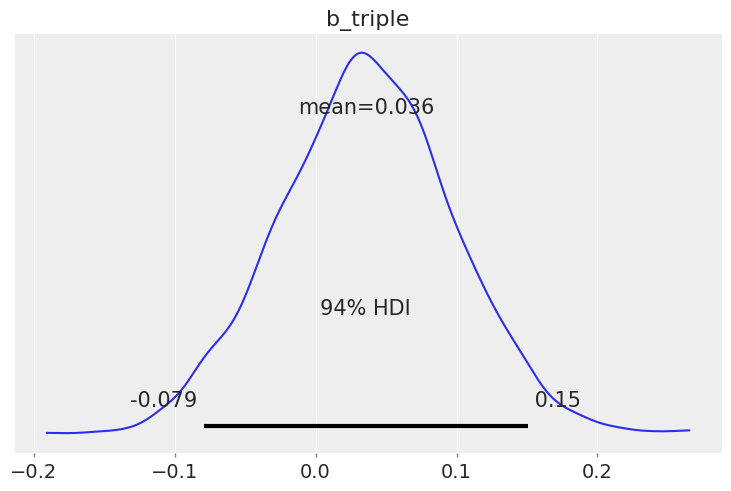

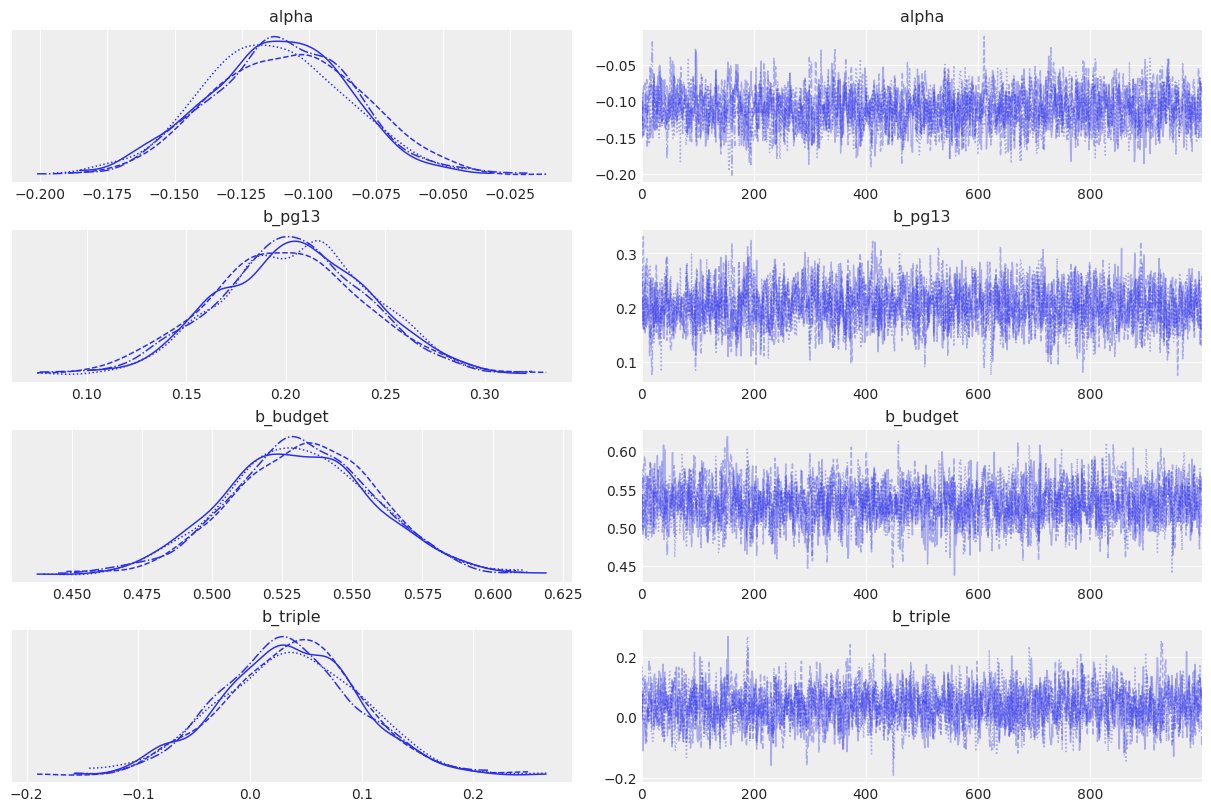

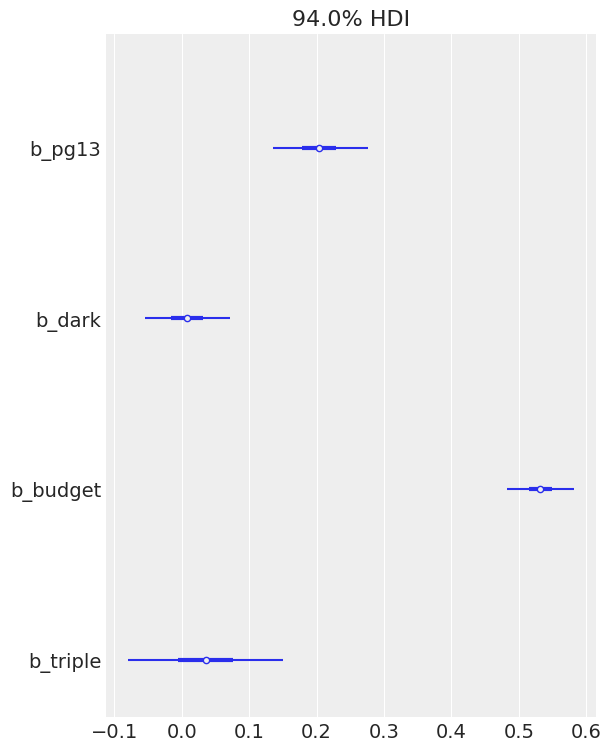

In [14]:
az.plot_posterior(idata_model1_extended_revenue, var_names=['b_triple'])
az.plot_trace(idata_model1_extended_revenue, var_names=['alpha', 'b_pg13', 'b_budget', 'b_triple'])
az.plot_forest(idata_model1_extended_revenue, var_names=['b_pg13', 'b_dark', 'b_budget', 'b_triple'], combined=True, hdi_prob=0.94)

#### Posterior predictive distribution

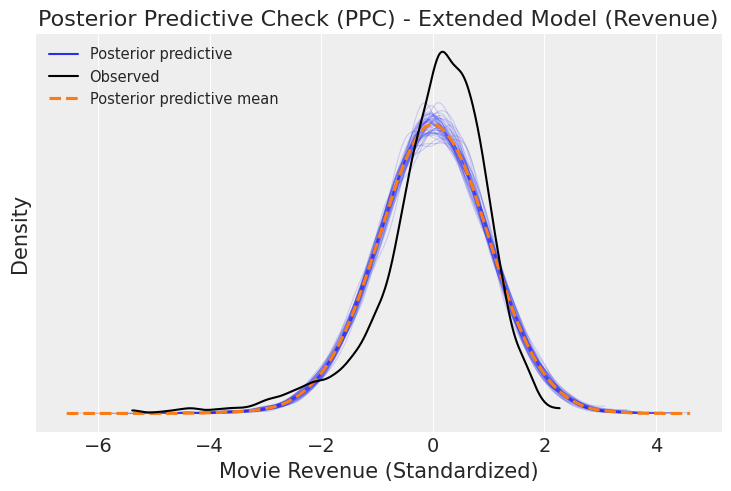

In [15]:
idata_extended_revenue = az.from_cmdstanpy(
    posterior=fit_model1_extended_revenue,
    posterior_predictive="y_rep",
    observed_data={"y": df_clean["std_gross"].values}
)

az.plot_ppc(idata_extended_revenue, data_pairs={"y": "y_rep"}, num_pp_samples=50, kind="kde")

plt.title("Posterior Predictive Check (PPC) - Extended Model (Revenue)")
plt.xlabel("Movie Revenue (Standardized)")
plt.ylabel("Density")
plt.show()

## Model 2 (Student's T distribution)

In [16]:
model2_extended = CmdStanModel(stan_file='stan/model2_extended.stan')


INFO:cmdstanpy:compiling stan file /home/AGH/DA/project/stan/model2_extended.stan to exe file /home/AGH/DA/project/stan/model2_extended


KeyboardInterrupt: 

In [ ]:
fit_model2_extended_revenue = model2_extended.sample(data=revenue_data_extended, chains=4, iter_sampling=1000, parallel_chains=4)

In [ ]:
idata_model2_extended_revenue = az.from_cmdstanpy(fit_model2_extended_revenue)

In [ ]:
comp = az.compare({"Base Model (Without PG-13)": idata_model1_baseline_revenue, "Extended model (Student-t) (With PG-13)": idata_model2_extended_revenue}, ic="loo")
print(comp)

az.plot_compare(comp)

In [ ]:
az.plot_posterior(idata_model2_extended_revenue, var_names=['b_triple'])
az.plot_trace(idata_model2_extended_revenue, var_names=['alpha', 'b_pg13', 'b_budget', 'b_triple'])
az.plot_forest(idata_model2_extended_revenue, var_names=['b_pg13', 'b_dark', 'b_budget', 'b_triple'], combined=True, hdi_prob=0.94)

In [ ]:
idata_model2_extended_revenue = az.from_cmdstanpy(
    posterior=fit_model2_extended_revenue,
    posterior_predictive="y_rep",
    observed_data={"y": df_clean["std_gross"].values}
)

az.plot_ppc(idata_model2_extended_revenue, data_pairs={"y": "y_rep"}, num_pp_samples=50, kind="kde")

plt.title("Posterior Predictive Check (PPC) - Extended Model (Student-t) (Revenue)")
plt.xlabel("Movie Revenue (Standardized)")
plt.ylabel("Density")
plt.show()